In [1]:
%matplotlib widget

# Perform Piecewise Inversion on Field data: Ackerdijkse Plassen

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import sys
sys.path.insert(1, '../src')

from FDEM1D import FDEM1DModelling_field
from showStitched import showStitchedModels
from sklearn.metrics import root_mean_squared_error

/tmp/ipykernel_1250729/1588764659.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# 1. Load data

Dataframe = pd.DataFrame(np.load('data/Field_data.npy'),
                        columns = ['X','Y','Position','Z','H2Q','H4Q','H8Q',
                                   'V2Q','V4Q','V8Q','P2Q','P4Q','P8Q',
                                   'H4IP','H8IP','V4IP','V8IP'])

In [4]:
Dataframe

,X,Y,Position,Z,H2Q,H4Q,H8Q,V2Q,V4Q,V8Q,P2Q,P4Q,P8Q,H4IP,H8IP,V4IP,V8IP
0,4.421889,51.975739,1.0,-2.675400,0.004598,0.022228,0.074302,0.002878,0.016571,0.077201,0.002742,0.017739,0.095344,0.006820,0.04980,0.002560,0.02815
1,4.421891,51.975745,2.0,-2.700714,0.004619,0.022143,0.073619,0.002928,0.016714,0.076178,0.002769,0.017963,0.095111,0.006755,0.04909,0.002630,0.02789
2,4.421893,51.975752,3.0,-2.748954,0.004676,0.022143,0.072880,0.002956,0.016685,0.076291,0.002875,0.018366,0.095694,0.006680,0.05008,0.002640,0.02762
3,4.421895,51.975758,4.0,-2.782702,0.004690,0.022086,0.072426,0.002985,0.016742,0.076405,0.002961,0.018515,0.095927,0.006790,0.04988,0.002610,0.02781
4,4.421897,51.975765,5.0,-2.852704,0.004722,0.022200,0.072823,0.003148,0.017225,0.076973,0.003067,0.018784,0.095986,0.006835,0.04946,0.002550,0.02729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1845,4.422503,51.975986,46.0,-3.128721,0.003674,0.018419,0.069242,0.003198,0.016984,0.080839,0.002452,0.014066,0.081124,0.005160,0.04214,0.002625,0.02946
1846,4.422505,51.975992,47.0,-3.068029,0.003631,0.018220,0.069583,0.002551,0.015804,0.076632,0.002413,0.013916,0.079726,0.004890,0.04159,0.002740,0.02768
1847,4.422507,51.975998,48.0,-3.036895,0.003457,0.017339,0.067423,0.003056,0.016188,0.076234,0.002096,0.012811,0.074947,0.004855,0.04127,0.002500,0.02676
1848,4.422509,51.976005,49.0,-2.976506,0.003247,0.016884,0.067082,0.003051,0.016022,0.075533,0.001747,0.011916,0.070051,0.004360,0.04055,0.002303,0.02670


In [5]:
# Obtain H and V quadrature and in-phase measurements
# For in-phase we only use measurements for offsets > 4 m
data = np.array(pd.concat([Dataframe.loc[:,'H2Q':'P8Q'], Dataframe.loc[:,'H4IP':]], axis=1))
npos = len(data) # number of 1D models
nlay = 2 # number of layers

In [6]:
# Acquisition parameters

freq = 9000
height = 0.47

In [7]:
# Setting forward operator 

fop = FDEM1DModelling_field(nlay=2)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(1/1000,500/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([3, 0.1, 0.1]) # initial model

model_inv = []
response = []

# Invert

In [8]:
for pos in range(npos):
    dat = data[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))
    response.append(inv.response)

In [9]:
Model_inv_frame =pd.DataFrame(model_inv, columns= ['h_1', 's_1', 's_2'])

In [10]:
Model_inv_frame

,h_1,s_1,s_2
0,1.142456,0.032283,0.133927
1,1.178066,0.034527,0.134758
2,1.200352,0.037993,0.134330
3,1.257733,0.041859,0.134207
4,1.234232,0.046222,0.131462
...,...,...,...
1845,2.011176,0.045477,0.134489
1846,1.966801,0.040184,0.133916
1847,1.987637,0.037378,0.130688
1848,1.689024,0.026145,0.121979


In [11]:
model_inv = np.array(model_inv)
responses = np.array(response)

air_layer = np.zeros_like(model_inv[:,0])
air_layer_height = -Dataframe['Z']

model_inv_topo = np.stack((air_layer_height, model_inv[:,0], air_layer, model_inv[:,1]*1000, model_inv[:,2]*1000), axis=1)

In [12]:
rmse_L1 = root_mean_squared_error(data[0:50], responses[0:50])*1000
rmse_L18 = root_mean_squared_error(data[900:950], responses[900:950])*1000
rmse_L36 = root_mean_squared_error(data[1800:], responses[1800:])*1000

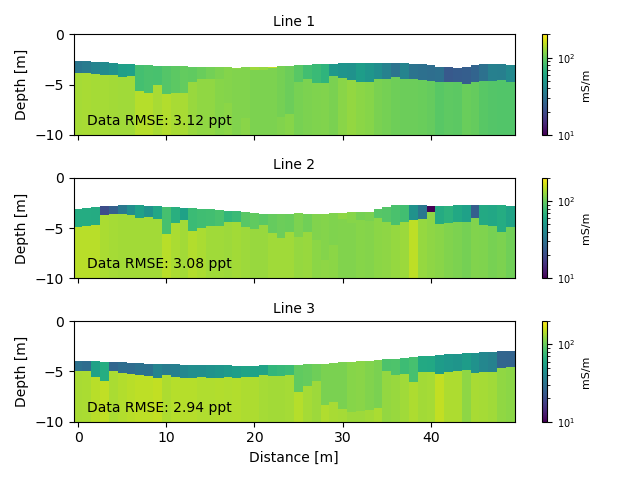

In [13]:
fig, ax = plt.subplots(3,1, sharex=True)

fs=10
showStitchedModels(model_inv_topo[0:50], ax=ax[0], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[0].set_title('Line 1', fontsize=fs)
ax[0].set_ylabel('Depth [m]', fontsize=fs)
ax[0].text(1, -9, 'Data RMSE: ' + format(rmse_L1, ".2f") + ' ppt')

showStitchedModels(model_inv_topo[900:950], ax=ax[1], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[1].set_title('Line 2', fontsize=fs)
ax[1].set_ylabel('Depth [m]', fontsize=fs)
ax[1].text(1, -9, 'Data RMSE: ' + format(rmse_L18, ".2f") + ' ppt')

showStitchedModels(model_inv_topo[1800:], ax=ax[2], zMax=10, cMin=10, cMax=200, label='mS/m')
ax[2].set_title('Line 3', fontsize=fs)
ax[2].set_ylabel('Depth [m]', fontsize=fs)
ax[2].set_xlabel('Distance [m]', fontsize=fs)
ax[2].text(1, -9, 'Data RMSE: ' + format(rmse_L36, ".2f") + ' ppt')

#fig.suptitle('PWI estimated models')
plt.tight_layout()
plt.savefig('figures/Lines_PWI.eps', format='eps')
plt.show()

In [14]:
X = Dataframe['X']
Y = Dataframe['Y']
h_1 = Model_inv_frame['h_1']
s_1 = Model_inv_frame['s_1']*1000
s_2 = Model_inv_frame['s_2']*1000

In [15]:
#plt.style.use('bmh')

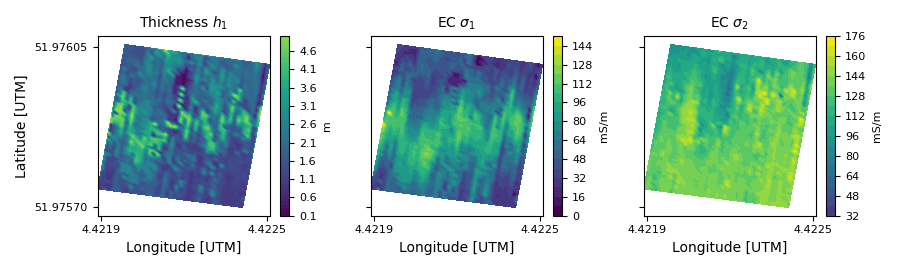

In [16]:
fig, ax = plt.subplots(1,3, figsize=(9,2.7), sharey=True)

fs=10

cb0 = ax[0].tricontourf(X, Y, h_1, vmin=0, vmax=6, levels=50, cmap='viridis',)
ax[0].set_title('Thickness $h_1$', fontsize=fs)
ax[0].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[0].set_ylabel('Latitude [UTM]', fontsize=fs)
ax[0].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[0].ticklabel_format(useOffset=False)
ax[0].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[0].tick_params(labelsize=8)


cb1 = ax[1].tricontourf(X, Y, np.array(s_1),  levels=20, cmap='viridis', vmin=5)
ax[1].set_title('EC $\sigma_1$', fontsize=fs)
ax[1].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[1].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[1].ticklabel_format(useOffset=False)
ax[1].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[1].tick_params(labelsize=8)

cb2 = ax[2].tricontourf(X, Y, np.array(s_2),  levels=20, cmap='viridis', vmin=5)
ax[2].set_title('EC $\sigma_2$', fontsize=fs)
ax[2].set_xlabel('Longitude [UTM]', fontsize=fs)
ax[2].set_yticks([np.round(np.min(Y),5), np.round(np.max(Y),5)])
ax[2].ticklabel_format(useOffset=False)
ax[2].set_xticks([np.round(np.min(X),4), np.round(np.max(X),4)])
ax[2].tick_params(labelsize=8)

c1 = fig.colorbar(cb0, ax=ax[0],)
c1.set_label('m', fontsize=8)
c1.ax.tick_params(labelsize=8)

c2 = fig.colorbar(cb1, ax=ax[1],  boundaries=(5, 300))
c2.set_label('mS/m', fontsize=8)
c2.ax.tick_params(labelsize=8)

c3 = fig.colorbar(cb2, ax=ax[2], boundaries=(5, 300))
c3.set_label('mS/m', fontsize=8)
c3.ax.tick_params(labelsize=8)

#fig.suptitle('PWI estimated models')

plt.tight_layout()
plt.savefig('figures/Maps_PWI.eps', format='eps')
plt.show()

In [17]:
data_inv = np.array(response)
data_inv = data_inv.reshape((37,50,13))

In [18]:
np.save('data/data_inv_PWI', data_inv)